In [ ]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rxr
import xarray as xr


# Figure 4: species-richness change and deforestation distance

This notebook compares future all-taxon species richness under the no-tipping and tipping-with-deforestation scenarios for 2050-2069. It uses the four taxon-specific mean SR rasters copied from step 07 and the binary deforestation map prepared for Figure 1.


In [ ]:
# Local inputs and output.
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "07_postprocess_data" / "local" / "species_richness_from_SDM_projections" / "data" / "results_mean_ETresid").is_dir()
)

sr_root = (
    repository_root
    / "07_postprocess_data"
    / "local"
    / "species_richness_from_SDM_projections"
    / "data"
    / "results_mean_ETresid"
)
deforestation_file = (
    repository_root
    / "08_figures"
    / "main_figures"
    / "figure_1"
    / "local"
    / "data"
    / "binary_defors_map_2050_2069.nc"
)
output_dir = repository_root / "08_figures" / "main_figures" / "figure_4" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

ssp = "ssp245"
time_period = "2050_2069"
scenarios = {
    "no_tipping": f"{ssp}_notip_no_deforestation",
    "tipping_deforestation": f"{ssp}_tip_deforestation",
}
taxon_groups = ["amphibians", "mammals", "reptiles", "birds_resident"]
amazon_extent = {"minx": -80, "miny": -20, "maxx": -50, "maxy": 5}


In [ ]:
def load_total_future_sr(scenario):
    """Load and sum the four taxon-specific future mean SR rasters."""
    rasters = [
        rxr.open_rasterio(
            sr_root / scenario / time_period / f"future_species_richness_mean_{taxon}.tif"
        ).squeeze()
        for taxon in taxon_groups
    ]
    return xr.concat(rasters, dim="taxon").sum("taxon", skipna=True, min_count=1).rio.clip_box(**amazon_extent)


def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres."""
    radius_km = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    angle = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return 2 * radius_km * np.arcsin(np.sqrt(angle))


def binned_statistics(x, y, bins):
    indices = np.clip(np.digitize(x, bins) - 1, 0, len(bins) - 2)
    statistics = []
    for index in range(len(bins) - 1):
        values = y[indices == index]
        if values.size:
            statistics.append((
                (bins[index] + bins[index + 1]) / 2,
                values.mean(),
                np.percentile(values, 5),
                np.percentile(values, 95),
            ))
    return np.asarray(statistics).T if statistics else (np.array([]),) * 4


In [ ]:
# Calculate future all-taxon SR change: tipping with deforestation minus no tipping.
sr_no_tipping = load_total_future_sr(scenarios["no_tipping"])
sr_tipping = load_total_future_sr(scenarios["tipping_deforestation"])
difference_sr = (sr_tipping - sr_no_tipping).sortby("y").rename({"x": "longitude", "y": "latitude"})

deforestation = xr.open_dataset(deforestation_file)["deforestation"]
lons, lats = deforestation.longitude.values, deforestation.latitude.values
lon_grid, lat_grid = np.meshgrid(lons, lats)

difference_values = difference_sr.values.ravel()
deforestation_values = deforestation.values.ravel()
deforested_lons = lon_grid.ravel()[deforestation_values == 1]
deforested_lats = lat_grid.ravel()[deforestation_values == 1]

# Mean great-circle distance from each cell to all deforested cells.
mean_distance_km = haversine_distance(
    lat_grid.ravel()[:, None], lon_grid.ravel()[:, None],
    deforested_lats[None, :], deforested_lons[None, :],
).mean(axis=1)

valid = np.isfinite(difference_values) & np.isfinite(mean_distance_km)
x_values = mean_distance_km[valid]
y_values = difference_values[valid]
bins = np.linspace(x_values.min(), x_values.max(), 16)
negative_stats = binned_statistics(x_values[y_values < 0], y_values[y_values < 0], bins)
positive_stats = binned_statistics(x_values[y_values > 0], y_values[y_values > 0], bins)


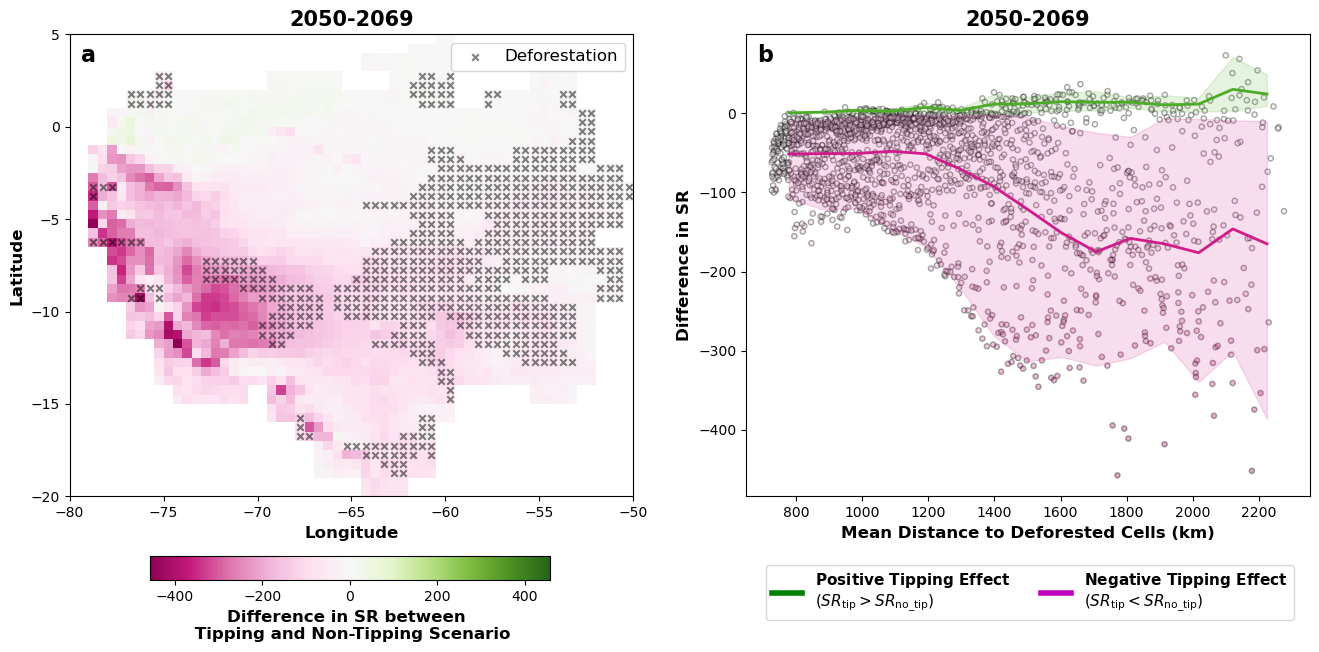

In [7]:
# Plot (styled to match the original Figure 4 layout).
title_period = time_period.replace("_", "-")
maximum_difference = np.nanmax(np.abs(difference_sr.values))
norm = mcolors.TwoSlopeNorm(vmin=-maximum_difference, vcenter=0, vmax=maximum_difference)
cmap = plt.cm.PiYG

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: map.
map_axis = axes[0]
image = map_axis.pcolormesh(lons, lats, difference_sr.values, cmap=cmap, norm=norm, shading="auto")
deforested = np.where(deforestation.values == 1)
map_axis.scatter(
    lons[deforested[1]], lats[deforested[0]],
    marker="x", color="black", alpha=0.5, s=22, label="Deforestation",
)
map_axis.set_title(title_period, fontsize=15, fontweight="bold")
map_axis.set_xlabel("Longitude", fontsize=12, fontweight="bold")
map_axis.set_ylabel("Latitude", fontsize=12, fontweight="bold")
map_axis.legend(loc="upper right", fontsize=12)

# Right panel: distance relationship.
scatter_axis = axes[1]
scatter_axis.scatter(
    x_values, y_values,
    c=cmap(norm(y_values)), s=14, alpha=0.35, edgecolor="black",
)
for stats, color in ((negative_stats, "#d01c8b"), (positive_stats, "#4dac26")):
    centers, means, lower, upper = stats
    scatter_axis.fill_between(centers, lower, upper, color=color, alpha=0.15)
    scatter_axis.plot(centers, means, color=color, lw=2)
scatter_axis.set_title(title_period, fontsize=15, fontweight="bold")
scatter_axis.set_xlabel("Mean Distance to Deforested Cells (km)", fontsize=12, fontweight="bold")
scatter_axis.set_ylabel("Difference in SR", fontsize=12, fontweight="bold")

# Colorbar and effect legend below the two panels, as in the original figure layout.
colorbar_axis = fig.add_axes([0.175, -0.03, 0.25, 0.04])
colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=colorbar_axis,
    orientation="horizontal",
)
colorbar.set_label(
    "Difference in SR between \n Tipping and Non-Tipping Scenario",
    fontsize=12,
    fontweight="bold",
)

legend_axis = fig.add_axes([0.55, -0.08, 0.35, 0.06])
legend_axis.axis("off")
legend_axis.legend(
    handles=[
        plt.Line2D(
            [], [], color="g", lw=4,
            label=r"$\mathbf{Positive\ Tipping\ Effect}$" "\n"
                  r"($SR_{\mathrm{tip}} > SR_{\mathrm{no\_tip}}$)",
        ),
        plt.Line2D(
            [], [], color="m", lw=4,
            label=r"$\mathbf{Negative\ Tipping\ Effect}$" "\n"
                  r"($SR_{\mathrm{tip}} < SR_{\mathrm{no\_tip}}$)",
        ),
    ],
    loc="center",
    ncol=2,
    fontsize=11,
)

for axis, letter in zip(axes, "ab"):
    axis.text(
        0.02, 0.98, letter,
        transform=axis.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.savefig(output_dir / "final_figure_4.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()
